In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        self.gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * self.gates
        output = F.linear(x, pruned_weights, self.bias)
        return output

In [3]:
def compute_sparsity_loss(model):
    sparsity_loss = 0
    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            sparsity_loss += layer.gates.sum()
    return sparsity_loss

In [4]:
tranform = transforms.Compose([transforms.ToTensor()])

In [5]:
train_set = datasets.CIFAR10('./data',train=True, download=True,transform=tranform)
test_set = datasets.CIFAR10('./data',train=False, download=False,transform=tranform)
train_loader = DataLoader(train_set, batch_size=32, num_workers=2, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, num_workers=2, shuffle=True)

100%|██████████| 170M/170M [00:04<00:00, 37.5MB/s]


In [6]:
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 128)
        self.fc4 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PrunableNet().to(device)

In [11]:
lambda_val = 0.001

optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(20):
    model.train()
    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        classification_loss = F.cross_entropy(output, target)
        sparsity_loss = compute_sparsity_loss(model)
        loss = classification_loss + lambda_val * sparsity_loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}:- Clasification Loss: {classification_loss.item()} | Sparsity Loss: {sparsity_loss.item()}")

Epoch 1:- Clasification Loss: 42.31566619873047 | Sparsity Loss: 655991.1875
Epoch 2:- Clasification Loss: 15.686603546142578 | Sparsity Loss: 546458.0625
Epoch 3:- Clasification Loss: 14.540830612182617 | Sparsity Loss: 457540.8125
Epoch 4:- Clasification Loss: 10.453295707702637 | Sparsity Loss: 381584.96875
Epoch 5:- Clasification Loss: 3.607563018798828 | Sparsity Loss: 316074.65625
Epoch 6:- Clasification Loss: 4.333447456359863 | Sparsity Loss: 258833.921875
Epoch 7:- Clasification Loss: 3.5410778522491455 | Sparsity Loss: 209029.71875
Epoch 8:- Clasification Loss: 2.2570388317108154 | Sparsity Loss: 166821.390625
Epoch 9:- Clasification Loss: 4.422135353088379 | Sparsity Loss: 131596.53125
Epoch 10:- Clasification Loss: 1.9974761009216309 | Sparsity Loss: 103301.203125
Epoch 11:- Clasification Loss: 1.3974058628082275 | Sparsity Loss: 81084.390625
Epoch 12:- Clasification Loss: 1.703012466430664 | Sparsity Loss: 64178.90234375
Epoch 13:- Clasification Loss: 2.7304036617279053 | 

In [12]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = torch.sigmoid(layer.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    sparsity = (pruned / total) * 100
    return sparsity

In [13]:
calculate_sparsity(model)

87.86766736632788

In [14]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)

            correct += (preds == target).sum().item()
            total += target.size(0)

    accuracy = (correct / total) * 100
    return accuracy

In [15]:
evaluate(model, test_loader)

45.59

In [19]:
lambda_values = [0.0001, 0.001, 0.01]
mods = []
results = []

for lam in lambda_values:

    print("\nTraining with lambda =", lam)

    model = PrunableNet()
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(20):
        model.train()

        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(data)
            classification_loss = F.cross_entropy(output, target)
            sparsity_loss = compute_sparsity_loss(model)

            loss = classification_loss + lam * sparsity_loss

            loss.backward()
            optimizer.step()

    sparsity = calculate_sparsity(model)
    accuracy = evaluate(model, test_loader)

    print("Sparsity:", sparsity)
    print("Accuracy:", accuracy)

    results.append((lam, sparsity, accuracy))
    mods.append(model)


Training with lambda = 0.0001
Sparsity: 49.16431911916335
Accuracy: 37.169999999999995

Training with lambda = 0.001
Sparsity: 81.63803579319487
Accuracy: 39.48

Training with lambda = 0.01
Sparsity: 97.6811063853292
Accuracy: 39.64


In [21]:
df = pd.DataFrame(results, columns=["Lambda", "Sparsity (%)", "Test Accuracy (%)"])
df

,Lambda,Sparsity (%),Test Accuracy (%)
0,0.0001,49.164319,37.17
1,0.0010,81.638036,39.48
2,0.0100,97.681106,39.64


In [22]:
def get_all_gates(model):
    all_gates = []

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = torch.sigmoid(layer.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    return all_gates

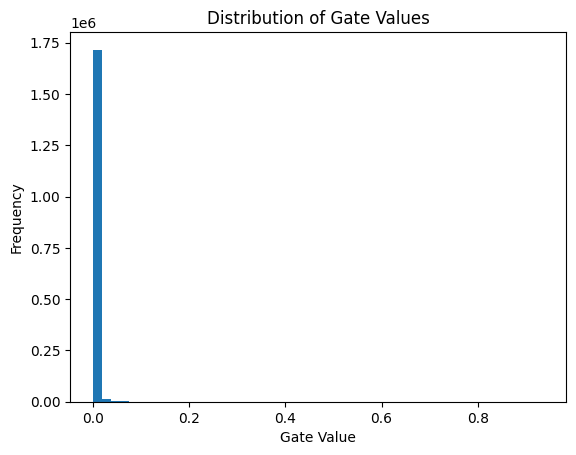

In [23]:
gates = get_all_gates(mods[2])

plt.figure()
plt.hist(gates, bins=50)

plt.title("Distribution of Gate Values")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")

plt.show()